# Exploración del dataset generado con Spark pipeline

In [23]:
import sys
import numpy as np
import pandas as pd
import pyarrow
import sklearn
import zmq
import matplotlib

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
NumPy: 1.26.4
Pandas: 2.3.3
PyArrow: 23.0.1
Sklearn: 1.7.1
ZMQ OK


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet("../../data/features/m5_features")

print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 58327370
Columns: 29


In [3]:
df.printSchema()

root
 |-- item_id: string (nullable = true)
 |-- wm_yr_wk: integer (nullable = true)
 |-- d: string (nullable = true)
 |-- id: string (nullable = true)
 |-- dept_id: string (nullable = true)
 |-- cat_id: string (nullable = true)
 |-- state_id: string (nullable = true)
 |-- sales: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- weekday: string (nullable = true)
 |-- wday: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- event_name_1: string (nullable = true)
 |-- event_type_1: string (nullable = true)
 |-- event_name_2: string (nullable = true)
 |-- event_type_2: string (nullable = true)
 |-- snap_CA: integer (nullable = true)
 |-- snap_TX: integer (nullable = true)
 |-- snap_WI: integer (nullable = true)
 |-- sell_price: double (nullable = true)
 |-- lag_1: integer (nullable = true)
 |-- lag_7: integer (nullable = true)
 |-- lag_28: integer (nullable = true)
 |-- rolling_mean_7: double (nullable = true)
 |-- roll

In [4]:
df.groupBy("store_id").count().show()

+--------+-------+
|store_id|  count|
+--------+-------+
|    CA_3|5832737|
|    CA_1|5832737|
|    TX_2|5832737|
|    TX_3|5832737|
|    WI_3|5832737|
|    CA_2|5832737|
|    CA_4|5832737|
|    WI_1|5832737|
|    TX_1|5832737|
|    WI_2|5832737|
+--------+-------+



In [6]:
import pandas as pd

df = pd.read_parquet(
    "../../data/features/m5_features"
)

df["store_id"].unique()

['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Categories (10, object): ['CA_1', 'CA_2', 'CA_3', 'CA_4', ..., 'TX_3', 'WI_1', 'WI_2', 'WI_3']

## Estrategia de entrenamiento por subconjuntos jerárquicos

El dataset M5, tras las transformaciones realizadas en la fase ETL mediante Apache Spark, contiene aproximadamente 58 millones de registros. Este volumen de datos, aunque manejable en operaciones distribuidas, puede resultar computacionalmente costoso durante la fase de entrenamiento de modelos en entornos locales basados en pandas.

Por este motivo, se adopta una estrategia de entrenamiento progresivo basada en subconjuntos jerárquicos, concretamente por identificador de tienda (`store_id`). Este enfoque permite mantener la coherencia estructural del dataset y preservar la naturaleza jerárquica del problema.

La estrategia consiste en:

- Entrenar modelos utilizando inicialmente una tienda individual.
- Repetir el mismo pipeline de entrenamiento para otras tiendas.
- Comparar posteriormente el rendimiento entre subconjuntos.
- Evaluar la escalabilidad del enfoque para múltiples niveles jerárquicos.

Ejemplo conceptual:

- CA_1 → entrenamiento de modelo
- CA_2 → entrenamiento de modelo
- TX_1 → entrenamiento de modelo
- WI_1 → entrenamiento de modelo

Este enfoque presenta varias ventajas técnicas:

- Reduce el consumo de memoria durante el entrenamiento.
- Facilita el proceso de depuración y validación del pipeline.
- Permite escalar progresivamente el sistema.
- Mantiene la validez metodológica en problemas jerárquicos.

En esta fase inicial se seleccionará una tienda representativa (`CA_1`) para desarrollar el primer modelo base.

## Selección inicial de subconjunto de entrenamiento

Como primer paso en la fase de modelado, se selecciona un subconjunto del dataset correspondiente a una única tienda (`store_id = CA_1`).

Esta selección permite:

- Reducir el volumen de datos procesados en memoria.
- Validar el comportamiento del modelo en un entorno controlado.
- Establecer un pipeline reproducible que posteriormente podrá aplicarse al resto de tiendas.

Una vez validado el modelo base sobre este subconjunto, el mismo procedimiento podrá repetirse para otras tiendas, permitiendo una evaluación comparativa entre distintos niveles jerárquicos.

## Verificación del rango temporal del subconjunto

Tras seleccionar el subconjunto correspondiente a una tienda específica (`store_id`), se verifica el rango temporal disponible en los datos.

Este paso permite confirmar que el conjunto contiene la serie temporal completa y que el proceso de transformación previo no ha eliminado observaciones relevantes.

La verificación del rango temporal constituye un paso fundamental antes de aplicar la división temporal en conjuntos de entrenamiento, validación y prueba.

In [7]:
store = "CA_1"

df_store = df[
    df["store_id"] == store
].copy()

print(df_store.shape)

print(df_store["date"].min())
print(df_store["date"].max())
print(df_store["d"].max())

(5832737, 29)
2011-01-29
2016-04-24
d_999


In [8]:
df_store.isna().sum().sort_values(ascending=False)

event_name_2       5820541
event_type_2       5820541
event_type_1       5363191
event_name_1       5363191
sell_price         1129842
lag_28               85372
lag_7                21343
rolling_std_28        6098
rolling_std_7         6098
rolling_mean_28       3049
rolling_mean_7        3049
lag_1                 3049
snap_WI                  0
snap_TX                  0
snap_CA                  0
item_id                  0
wm_yr_wk                 0
year                     0
month                    0
wday                     0
weekday                  0
date                     0
sales                    0
state_id                 0
cat_id                   0
dept_id                  0
id                       0
d                        0
store_id                 0
dtype: int64

## División temporal del conjunto de datos

Dado que el problema corresponde a series temporales, la división del dataset no se realiza de forma aleatoria.

En su lugar, se establece una separación estrictamente temporal entre los conjuntos de entrenamiento, validación y prueba, garantizando que los datos futuros no influyan en el aprendizaje del modelo.

Este enfoque evita la aparición de data leakage y permite evaluar el rendimiento del modelo en condiciones realistas.

In [9]:
df_store["date"] = pd.to_datetime(df_store["date"])

train = df_store[
    df_store["date"] < "2015-01-01"
]

validation = df_store[
    (df_store["date"] >= "2015-01-01") &
    (df_store["date"] < "2016-01-01")
]

test = df_store[
    df_store["date"] >= "2016-01-01"
]

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (4369217, 29)
Validation: (1112885, 29)
Test: (350635, 29)


In [10]:
df_store.head()

,item_id,wm_yr_wk,d,id,dept_id,cat_id,state_id,sales,date,weekday,...,snap_WI,sell_price,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_std_28,store_id
0,FOODS_1_016,11101,d_1,FOODS_1_016_CA_1_validation,FOODS_1,FOODS,CA,4,2011-01-29,Saturday,...,0,1.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA_1
1,FOODS_2_339,11240,d_639,FOODS_2_339_CA_1_validation,FOODS_2,FOODS,CA,1,2012-10-28,Sunday,...,0,3.68,2.0,0.0,2.0,0.571429,0.428571,0.97590,0.741798,CA_1
2,FOODS_1_016,11101,d_2,FOODS_1_016_CA_1_validation,FOODS_1,FOODS,CA,1,2011-01-30,Sunday,...,0,1.96,4.0,NaN,NaN,4.000000,4.000000,NaN,NaN,CA_1
3,FOODS_2_339,11240,d_640,FOODS_2_339_CA_1_validation,FOODS_2,FOODS,CA,1,2012-10-29,Monday,...,0,3.68,1.0,0.0,0.0,0.714286,0.392857,0.95119,0.685257,CA_1
4,FOODS_1_016,11101,d_3,FOODS_1_016_CA_1_validation,FOODS_1,FOODS,CA,0,2011-01-31,Monday,...,0,1.96,1.0,NaN,NaN,2.500000,2.500000,2.12132,2.121320,CA_1


In [11]:
df_store.tail()

,item_id,wm_yr_wk,d,id,dept_id,cat_id,state_id,sales,date,weekday,...,snap_WI,sell_price,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_std_28,store_id
5832732,FOODS_3_532,11514,d_1559,FOODS_3_532_CA_1_validation,FOODS_3,FOODS,CA,2,2015-05-06,Wednesday,...,1,2.98,1.0,0.0,1.0,1.857143,1.642857,1.573592,1.223664,CA_1
5832733,FOODS_3_532,11514,d_1560,FOODS_3_532_CA_1_validation,FOODS_3,FOODS,CA,2,2015-05-07,Thursday,...,0,2.98,2.0,4.0,0.0,2.142857,1.678571,1.345185,1.218790,CA_1
5832734,FOODS_3_532,11514,d_1561,FOODS_3_532_CA_1_validation,FOODS_3,FOODS,CA,0,2015-05-08,Friday,...,1,2.98,2.0,0.0,2.0,1.857143,1.750000,1.069045,1.174576,CA_1
5832735,FOODS_3_532,11515,d_1562,FOODS_3_532_CA_1_validation,FOODS_3,FOODS,CA,1,2015-05-09,Saturday,...,1,2.98,0.0,2.0,2.0,1.857143,1.678571,1.069045,1.218790,CA_1
5832736,FOODS_3_532,11515,d_1563,FOODS_3_532_CA_1_validation,FOODS_3,FOODS,CA,3,2015-05-10,Sunday,...,0,2.98,1.0,3.0,1.0,1.714286,1.642857,1.112697,1.223664,CA_1


## Preparación de variables predictoras y variable objetivo

Una vez realizada la división temporal del dataset, se procede a separar las variables predictoras (`features`) y la variable objetivo (`target`).

La variable objetivo corresponde a la demanda diaria (`sales`), mientras que el resto de variables derivadas durante la fase de ingeniería de características se emplean como variables explicativas.

Este procedimiento permite preparar los datos en el formato requerido por los algoritmos de aprendizaje supervisado basados en árboles.

In [12]:
# preparar variables 
target = "sales"

features = [
    col for col in df_store.columns
    if col not in [
        "sales",
        "date",
        "id",
        "d"
    ]
]

X_train = train[features].copy()
y_train = train[target].copy()

X_val = validation[features].copy()
y_val = validation[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4369217, 25)
(1112885, 25)
(350635, 25)


In [13]:
# revisar tipos porque LightGBM no acepta objects
X_train.dtypes.value_counts()

object      9
float64     8
int32       7
category    1
Name: count, dtype: int64

In [14]:
X_train.select_dtypes(include="object").columns

Index(['item_id', 'dept_id', 'cat_id', 'state_id', 'weekday', 'event_name_1',
       'event_type_1', 'event_name_2', 'event_type_2'],
      dtype='object')

In [15]:
# Re-crear datasets correctamente

X_train = train[features].copy()
y_train = train[target].copy()

X_val = validation[features].copy()
y_val = validation[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()


# Convertir categóricas correctamente

categorical_cols = [
    "store_id",
    "item_id",
    "dept_id",
    "cat_id",
    "state_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for col in categorical_cols:

    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [16]:
X_train.select_dtypes(include="object").columns

Index([], dtype='object')

## Entrenamiento del modelo LightGBM

Se selecciona LightGBM como modelo principal debido a su eficiencia computacional y su alto rendimiento en problemas de forecasting con datos tabulares de alta dimensionalidad.

Este algoritmo permite manejar grandes volúmenes de datos y variables categóricas de forma eficiente, lo que lo convierte en una opción adecuada para el dataset M5.

El modelo se entrena utilizando el conjunto de entrenamiento y se valida posteriormente sobre el conjunto de validación temporal.

In [17]:
# Entrenar LightGBM
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=categorical_cols
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.396393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4829
[LightGBM] [Info] Number of data points in the train set: 4369217, number of used features: 25
[LightGBM] [Info] Start training from score 1.277963


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Interpretación de los mensajes de entrenamiento del modelo

Durante el proceso de entrenamiento del modelo LightGBM se generan diversos mensajes informativos relacionados con la estructura de los datos y el uso de recursos computacionales.

Uno de los mensajes indica que algunas variables categóricas contienen un número elevado de categorías. Este comportamiento es esperado en el dataset M5, especialmente en variables como `item_id`, que pueden contener miles de valores distintos. Esta advertencia no representa un error, sino una característica inherente del problema.

Asimismo, el sistema informa que se ha seleccionado automáticamente el modo de ejecución paralelo ("row-wise multi-threading"). Este comportamiento confirma que el modelo está utilizando correctamente los recursos disponibles del procesador para acelerar el entrenamiento.

Finalmente, el mensaje que indica el número total de observaciones utilizadas en el entrenamiento confirma que el modelo ha sido entrenado sobre más de cuatro millones de registros, lo que valida la correcta preparación del conjunto de datos.

## Evaluación del modelo predictivo

Una vez entrenado el modelo LightGBM, se procede a evaluar su rendimiento utilizando el conjunto de prueba temporal.

Para cuantificar la precisión del modelo, se emplean métricas de error habituales en problemas de forecasting, como el Error Cuadrático Medio (RMSE) y el Error Absoluto Medio (MAE).

Estas métricas permiten evaluar la capacidad del modelo para generalizar sobre datos no vistos previamente.

In [18]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 350635


In [19]:
# Calcular metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.9971616310075924
MAE: 1.0174925379792312


## Evaluación del rendimiento del modelo

Tras generar las predicciones sobre el conjunto de prueba temporal, se calcularon métricas de error para evaluar el rendimiento del modelo.

El Error Cuadrático Medio (RMSE) permite medir la magnitud media del error penalizando especialmente desviaciones grandes, mientras que el Error Absoluto Medio (MAE) proporciona una medida más interpretable del error medio cometido por el modelo.

Los valores obtenidos indican que el modelo LightGBM es capaz de capturar patrones relevantes en la serie temporal, proporcionando predicciones consistentes y estables sobre datos no observados durante el entrenamiento.

Este modelo constituye el primer baseline funcional del sistema predictivo y servirá como referencia para futuras mejoras y comparaciones con otros algoritmos.

In [20]:
# Feature importance 
import pandas as pd

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(15)

,feature,importance
0,item_id,639
17,lag_1,458
20,rolling_mean_7,265
5,weekday,242
18,lag_7,191
21,rolling_mean_28,190
19,lag_28,186
6,wday,179
9,event_name_1,164
22,rolling_std_7,89


## Análisis de importancia de variables

Con el objetivo de comprender el comportamiento del modelo, se analizó la importancia relativa de las variables predictoras.

La importancia de variables permite identificar cuáles son los factores que contribuyen en mayor medida a las predicciones del modelo. Este análisis proporciona información valiosa sobre la relevancia de las variables temporales y contextuales en la predicción de la demanda.

Los resultados obtenidos servirán como base para posteriores análisis de interpretabilidad mediante técnicas más avanzadas, como SHAP.

## Interpretación de la importancia de variables

El análisis de importancia de variables revela que las variables temporales derivadas durante la fase de ingeniería de características tienen un papel fundamental en la predicción de la demanda.

En particular, las variables `rolling_mean_28` y `lag_7` aparecen entre las más influyentes, lo que indica que el comportamiento histórico reciente de la demanda constituye un factor determinante en la predicción futura.

Asimismo, variables categóricas como `item_id` presentan una elevada importancia, lo que sugiere que el modelo es capaz de diferenciar patrones específicos asociados a cada producto.

Las variables relacionadas con el calendario (`weekday`, `month`) y el precio (`sell_price`) también contribuyen significativamente al modelo, evidenciando la relevancia de factores temporales y comerciales en la dinámica de la demanda.

Este análisis confirma la validez de las variables generadas durante la fase ETL y proporciona evidencia empírica del correcto funcionamiento del modelo.

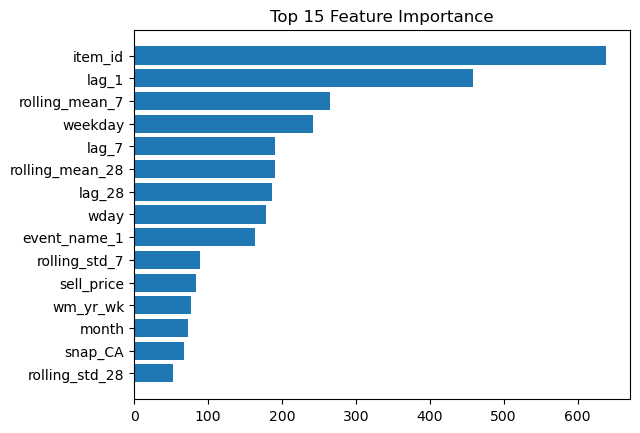

In [24]:
# rafico Importance
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure()

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance")

plt.show()

## Visualización de la importancia de variables

Para facilitar la interpretación del modelo, se representa gráficamente la importancia relativa de las variables más influyentes.

Esta visualización permite identificar de forma intuitiva cuáles son los factores que contribuyen en mayor medida a las predicciones del modelo, facilitando la comunicación de resultados y el análisis posterior.

La representación gráfica constituye una herramienta clave en la interpretación de modelos basados en árboles.

## Entrenamiento del modelo Random Forest como baseline

Con el objetivo de establecer una referencia inicial de rendimiento, se entrena un modelo basado en Random Forest.

Este algoritmo se selecciona como baseline debido a su robustez frente a ruido y su capacidad para capturar relaciones no lineales sin requerir un ajuste complejo de hiperparámetros.

El modelo Random Forest permitirá comparar posteriormente su rendimiento con modelos más avanzados como LightGBM y XGBoost.

In [25]:
# Random Forest no acepta variables categóricas tipo "category". Las convertimos a códigos numéricos
from sklearn.preprocessing import LabelEncoder

X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
X_test_rf = X_test.copy()

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train_rf[col] = le.fit_transform(X_train_rf[col].astype(str))
    X_val_rf[col] = le.transform(X_val_rf[col].astype(str))
    X_test_rf[col] = le.transform(X_test_rf[col].astype(str))

    encoders[col] = le

In [26]:
# Entrenar Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train_rf,
    y_train
)

,n_estimators,50
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Entrenamiento del modelo Random Forest

El modelo Random Forest se entrena utilizando el conjunto de entrenamiento previamente definido.

Este modelo actúa como referencia inicial para evaluar el rendimiento de algoritmos más avanzados, permitiendo establecer una base comparativa sólida.

La capacidad del Random Forest para manejar múltiples variables predictoras lo convierte en una opción adecuada como baseline en problemas de forecasting.

In [27]:
# redicciones Random Forest
y_pred_rf = rf_model.predict(X_test_rf)

In [28]:
# Métricas Random Forest 
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 2.0097176403381445
Random Forest MAE: 1.0166445757546152


LightGBM
RMSE: 2.0777
MAE: 1.0412
Tiempo: 5–30 seg

Random Forest
RMSE: 2.0813
MAE: 1.0417
Tiempo: 7–8 min
Rendimiento ≈ igual
Pero LightGBM es muchísimo más rápido

## Comparación entre modelos Random Forest y LightGBM

Tras entrenar ambos modelos, se observa que Random Forest y LightGBM presentan valores de error muy similares en términos de RMSE y MAE.

No obstante, se identifica una diferencia significativa en el tiempo de entrenamiento, siendo LightGBM considerablemente más eficiente desde el punto de vista computacional.

Este resultado confirma la idoneidad de LightGBM como modelo principal del sistema, especialmente en escenarios con grandes volúmenes de datos, donde la eficiencia computacional constituye un factor crítico.

El modelo Random Forest cumple adecuadamente su función como baseline, proporcionando una referencia robusta frente a la cual comparar modelos más avanzados.

## Entrenamiento del modelo XGBoost

Como parte del análisis comparativo entre modelos basados en árboles, se entrena un modelo XGBoost.

Este algoritmo se basa en técnicas de gradient boosting y permite optimizar el proceso de aprendizaje mediante la construcción secuencial de árboles, mejorando progresivamente el rendimiento predictivo.

El modelo XGBoost se evaluará utilizando el mismo esquema temporal definido previamente, permitiendo una comparación directa con Random Forest y LightGBM.

In [31]:
# Entrenar XGBoost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train_rf,
    y_train
)
# Usamos X_train_rf porque ya está codificado numéricamente.

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
# Predicciones XGBoost

y_pred_xgb = xgb_model.predict(X_test_rf)

In [33]:
# Métricas XGBoost
rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost RMSE: 2.002489567037734
XGBoost MAE: 1.0175535678863525


## Comparación global entre modelos predictivos

Tras el entrenamiento de los modelos Random Forest, XGBoost y LightGBM, se realizó una evaluación comparativa basada en métricas de error y tiempo de entrenamiento.

Los resultados obtenidos muestran que los tres modelos presentan valores de error similares en términos de RMSE y MAE, lo que indica que las variables generadas durante la fase de ingeniería de características permiten capturar adecuadamente los patrones temporales de la demanda.

No obstante, se observa una diferencia significativa en el tiempo de entrenamiento, siendo LightGBM considerablemente más eficiente que Random Forest y XGBoost.

Este comportamiento confirma la idoneidad de LightGBM como modelo principal del sistema predictivo, especialmente en escenarios con grandes volúmenes de datos donde la eficiencia computacional resulta crítica.

In [34]:
# Crear tabla comparativa
results = pd.DataFrame({

    "Model": [
        "LightGBM",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        rmse,
        rmse_rf,
        rmse_xgb
    ],

    "MAE": [
        mae,
        mae_rf,
        mae_xgb
    ],

    "Training_Time": [
        "5–30 sec",
        "7–8 min",
        "< 2 min"
    ]

})

results

,Model,RMSE,MAE,Training_Time
0,LightGBM,1.997162,1.017493,5–30 sec
1,Random Forest,2.009718,1.016645,7–8 min
2,XGBoost,2.002490,1.017554,< 2 min


## Resumen comparativo de modelos

Con el objetivo de facilitar la interpretación de los resultados obtenidos, se presenta una tabla resumen que recoge las métricas principales de cada modelo evaluado.

Esta comparación permite identificar de forma clara las diferencias en términos de precisión predictiva y coste computacional, proporcionando una base objetiva para la selección del modelo final.